# 🛠️ Preparação dos Dados

## Extração do Arquivo Tratado

In [24]:
import pandas as pd

caminho_arquivo = '/content/dados_tratados.csv'

df_telecom = pd.read_csv(caminho_arquivo)

display(df_telecom.head())

df_telecom.info()

,ID_Cliente,Cancelou,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Diaria,Cobranca_Total,Total_Servicos
0,0002-ORFBO,0,Feminino,0,1,1,9,1,0,DSL,...,1,1,0,Anual,1,Cheque Impresso,65.6,2.19,593.30,4
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,1,Mensal,0,Cheque Impresso,59.9,2.00,542.40,3
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fibra Optica,...,0,0,0,Mensal,1,Cheque Eletronico,73.9,2.46,280.85,2
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fibra Optica,...,0,1,1,Mensal,1,Cheque Eletronico,98.0,3.27,1237.85,5
4,0013-EXCHZ,1,Feminino,1,1,0,3,1,0,Fibra Optica,...,1,1,0,Mensal,1,Cheque Impresso,83.9,2.80,267.40,3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Cliente            7043 non-null   object 
 1   Cancelou              7043 non-null   int64  
 2   Genero                7043 non-null   object 
 3   Idoso                 7043 non-null   int64  
 4   Parceiro              7043 non-null   int64  
 5   Dependentes           7043 non-null   int64  
 6   Meses_Contrato        7043 non-null   int64  
 7   Servico_Telefone      7043 non-null   int64  
 8   Multiplas_Linhas      7043 non-null   int64  
 9   Servico_Internet      7043 non-null   object 
 10  Seguranca_Online      7043 non-null   int64  
 11  Backup_Online         7043 non-null   int64  
 12  Protecao_Dispositivo  7043 non-null   int64  
 13  Suporte_Tecnico       7043 non-null   int64  
 14  Streaming_TV          7043 non-null   int64  
 15  Streaming_Filmes     

## Remoção de Colunas Irrelevantes

In [25]:
df_telecom = df_telecom.drop('ID_Cliente', axis=1)

print("Colunas após a remoção do ID:")
print(df_telecom.columns.tolist())

Colunas após a remoção do ID:
['Cancelou', 'Genero', 'Idoso', 'Parceiro', 'Dependentes', 'Meses_Contrato', 'Servico_Telefone', 'Multiplas_Linhas', 'Servico_Internet', 'Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes', 'Tipo_Contrato', 'Fatura_Digital', 'Metodo_Pagamento', 'Cobranca_Mensal', 'Cobranca_Diaria', 'Cobranca_Total', 'Total_Servicos']


## Encoding

In [26]:
colunas_categoricas = df_telecom.select_dtypes(include=['object']).columns.tolist()
print(f"Colunas que serão transformadas: {colunas_categoricas}\n")

df_telecom_encoded = pd.get_dummies(df_telecom, columns=colunas_categoricas, drop_first=True)

colunas_booleanas = df_telecom_encoded.select_dtypes(include=['bool']).columns
df_telecom_encoded[colunas_booleanas] = df_telecom_encoded[colunas_booleanas].astype(int)

display(df_telecom_encoded.head())

print(f"\nO dataset agora tem {df_telecom_encoded.shape[0]} linhas e {df_telecom_encoded.shape[1]} colunas.")
print("Todas as colunas atuais:", df_telecom_encoded.columns.tolist())

Colunas que serão transformadas: ['Genero', 'Servico_Internet', 'Tipo_Contrato', 'Metodo_Pagamento']



,Cancelou,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Seguranca_Online,Backup_Online,Protecao_Dispositivo,...,Cobranca_Total,Total_Servicos,Genero_Masculino,Servico_Internet_Fibra Optica,Servico_Internet_Nenhum,Tipo_Contrato_Bienal,Tipo_Contrato_Mensal,Metodo_Pagamento_Cheque Eletronico,Metodo_Pagamento_Cheque Impresso,Metodo_Pagamento_Transferencia Bancaria (Auto)
0,0,0,1,1,9,1,0,0,1,0,...,593.30,4,0,0,0,0,0,0,1,0
1,0,0,0,0,9,1,1,0,0,0,...,542.40,3,1,0,0,0,1,0,1,0
2,1,0,0,0,4,1,0,0,0,1,...,280.85,2,1,1,0,0,1,1,0,0
3,1,1,1,0,13,1,0,0,1,1,...,1237.85,5,1,1,0,0,1,1,0,0
4,1,1,1,0,3,1,0,0,0,0,...,267.40,3,0,1,0,0,1,0,1,0



O dataset agora tem 7043 linhas e 26 colunas.
Todas as colunas atuais: ['Cancelou', 'Idoso', 'Parceiro', 'Dependentes', 'Meses_Contrato', 'Servico_Telefone', 'Multiplas_Linhas', 'Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes', 'Fatura_Digital', 'Cobranca_Mensal', 'Cobranca_Diaria', 'Cobranca_Total', 'Total_Servicos', 'Genero_Masculino', 'Servico_Internet_Fibra Optica', 'Servico_Internet_Nenhum', 'Tipo_Contrato_Bienal', 'Tipo_Contrato_Mensal', 'Metodo_Pagamento_Cheque Eletronico', 'Metodo_Pagamento_Cheque Impresso', 'Metodo_Pagamento_Transferencia Bancaria (Auto)']


## Verificação da Proporção de Evasão

In [27]:
contagem_absoluta = df_telecom_encoded['Cancelou'].value_counts()

proporcao = df_telecom_encoded['Cancelou'].value_counts(normalize=True) * 100

tabela_balanceamento = pd.DataFrame({
    'Quantidade (Clientes)': contagem_absoluta,
    'Proporção (%)': proporcao.round(2)
})

tabela_balanceamento.index = ['Não Cancelou (0)', 'Cancelou (1)']

print("--- Distribuição da Variável Alvo (Cancelou) ---")
display(tabela_balanceamento)

--- Distribuição da Variável Alvo (Cancelou) ---


,Quantidade (Clientes),Proporção (%)
Não Cancelou (0),5174,73.46
Cancelou (1),1869,26.54


## Verificação da Proporção de Evasão

In [28]:
contagem = df_telecom_encoded['Cancelou'].value_counts()
proporcao = df_telecom_encoded['Cancelou'].value_counts(normalize=True) * 100

print("--- PROPORÇÃO DE EVASÃO (CHURN) ---")
for classe, valor in contagem.items():
    status = "Evadiu (1)" if classe == 1 else "Permaneceu Ativo (0)"
    print(f"{status}: {valor} clientes ({proporcao[classe]:.2f}%)")

print("\n--- AVALIAÇÃO DE DESEQUILÍBRIO ---")
if proporcao[1] < 40.0:
    print("Resultado: Há um desequilíbrio significativo entre as classes.")
    print("\nImpactos nos Modelos Preditivos e na Análise:")
    print("- Viés de Aprendizado: O modelo tende a favorecer a classe majoritária (0), ignorando os padrões da classe minoritária (1).")
    print("- Falsa Alta Acurácia: O modelo pode alcançar alta acurácia simplesmente prevendo que ninguém vai cancelar, o que não resolve o problema de negócio.")
    print("- Métricas Enganosas: A acurácia global torna-se uma métrica ruim. Será necessário focar em Recall, Precision e F1-Score para a classe 1.")
    print("- Necessidade de Tratamento: Será recomendável aplicar técnicas como balanceamento de dados (ex: SMOTE, Undersampling) ou ajuste de pesos (class_weight) durante o treinamento.")
else:
    print("Resultado: As classes estão relativamente balanceadas. Os modelos não devem sofrer com viés de classe majoritária.")

--- PROPORÇÃO DE EVASÃO (CHURN) ---
Permaneceu Ativo (0): 5174 clientes (73.46%)
Evadiu (1): 1869 clientes (26.54%)

--- AVALIAÇÃO DE DESEQUILÍBRIO ---
Resultado: Há um desequilíbrio significativo entre as classes.

Impactos nos Modelos Preditivos e na Análise:
- Viés de Aprendizado: O modelo tende a favorecer a classe majoritária (0), ignorando os padrões da classe minoritária (1).
- Falsa Alta Acurácia: O modelo pode alcançar alta acurácia simplesmente prevendo que ninguém vai cancelar, o que não resolve o problema de negócio.
- Métricas Enganosas: A acurácia global torna-se uma métrica ruim. Será necessário focar em Recall, Precision e F1-Score para a classe 1.
- Necessidade de Tratamento: Será recomendável aplicar técnicas como balanceamento de dados (ex: SMOTE, Undersampling) ou ajuste de pesos (class_weight) durante o treinamento.


## Balanceamento de Classes

In [37]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df_telecom_encoded.drop('Cancelou', axis=1)
y = df_telecom_encoded['Cancelou']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(" ANTES DO SMOTE (Apenas base de Treino):")
print(y_train.value_counts())
print("-" * 40)

smote = SMOTE(random_state=42)
X_train_balanceado, y_train_balanceado = smote.fit_resample(X_train, y_train)

print(" DEPOIS DO SMOTE (Apenas base de Treino):")
print(y_train_balanceado.value_counts())
print("-" * 40)

print(f"Tamanho final do conjunto de Treino balanceado: {X_train_balanceado.shape[0]} linhas")
print(f"Tamanho do conjunto de Teste (intacto/mundo real): {X_test.shape[0]} linhas")

 ANTES DO SMOTE (Apenas base de Treino):
Cancelou
0    4139
1    1495
Name: count, dtype: int64
----------------------------------------
 DEPOIS DO SMOTE (Apenas base de Treino):
Cancelou
0    4139
1    4139
Name: count, dtype: int64
----------------------------------------
Tamanho final do conjunto de Treino balanceado: 8278 linhas
Tamanho do conjunto de Teste (intacto/mundo real): 1409 linhas


## Normalização ou Padronização

In [30]:
from sklearn.preprocessing import StandardScaler

colunas_continuas = ['Meses_Contrato', 'Cobranca_Mensal', 'Cobranca_Total']

scaler = StandardScaler()

X_train_balanceado_scaled = X_train_balanceado.copy()
X_train_balanceado_scaled[colunas_continuas] = scaler.fit_transform(X_train_balanceado[colunas_continuas])

X_test_scaled = X_test.copy()
X_test_scaled[colunas_continuas] = scaler.transform(X_test[colunas_continuas])

print(" Padronização concluída com sucesso!")
print("\nExemplo das médias das variáveis contínuas no Treino (devem ser muito próximas a 0):")
print(X_train_balanceado_scaled[colunas_continuas].mean().round(4))

 Padronização concluída com sucesso!

Exemplo das médias das variáveis contínuas no Treino (devem ser muito próximas a 0):
Meses_Contrato    -0.0
Cobranca_Mensal   -0.0
Cobranca_Total     0.0
dtype: float64


# 🎯 Correlação e Seleção de Variáveis

## Análise de Correlação

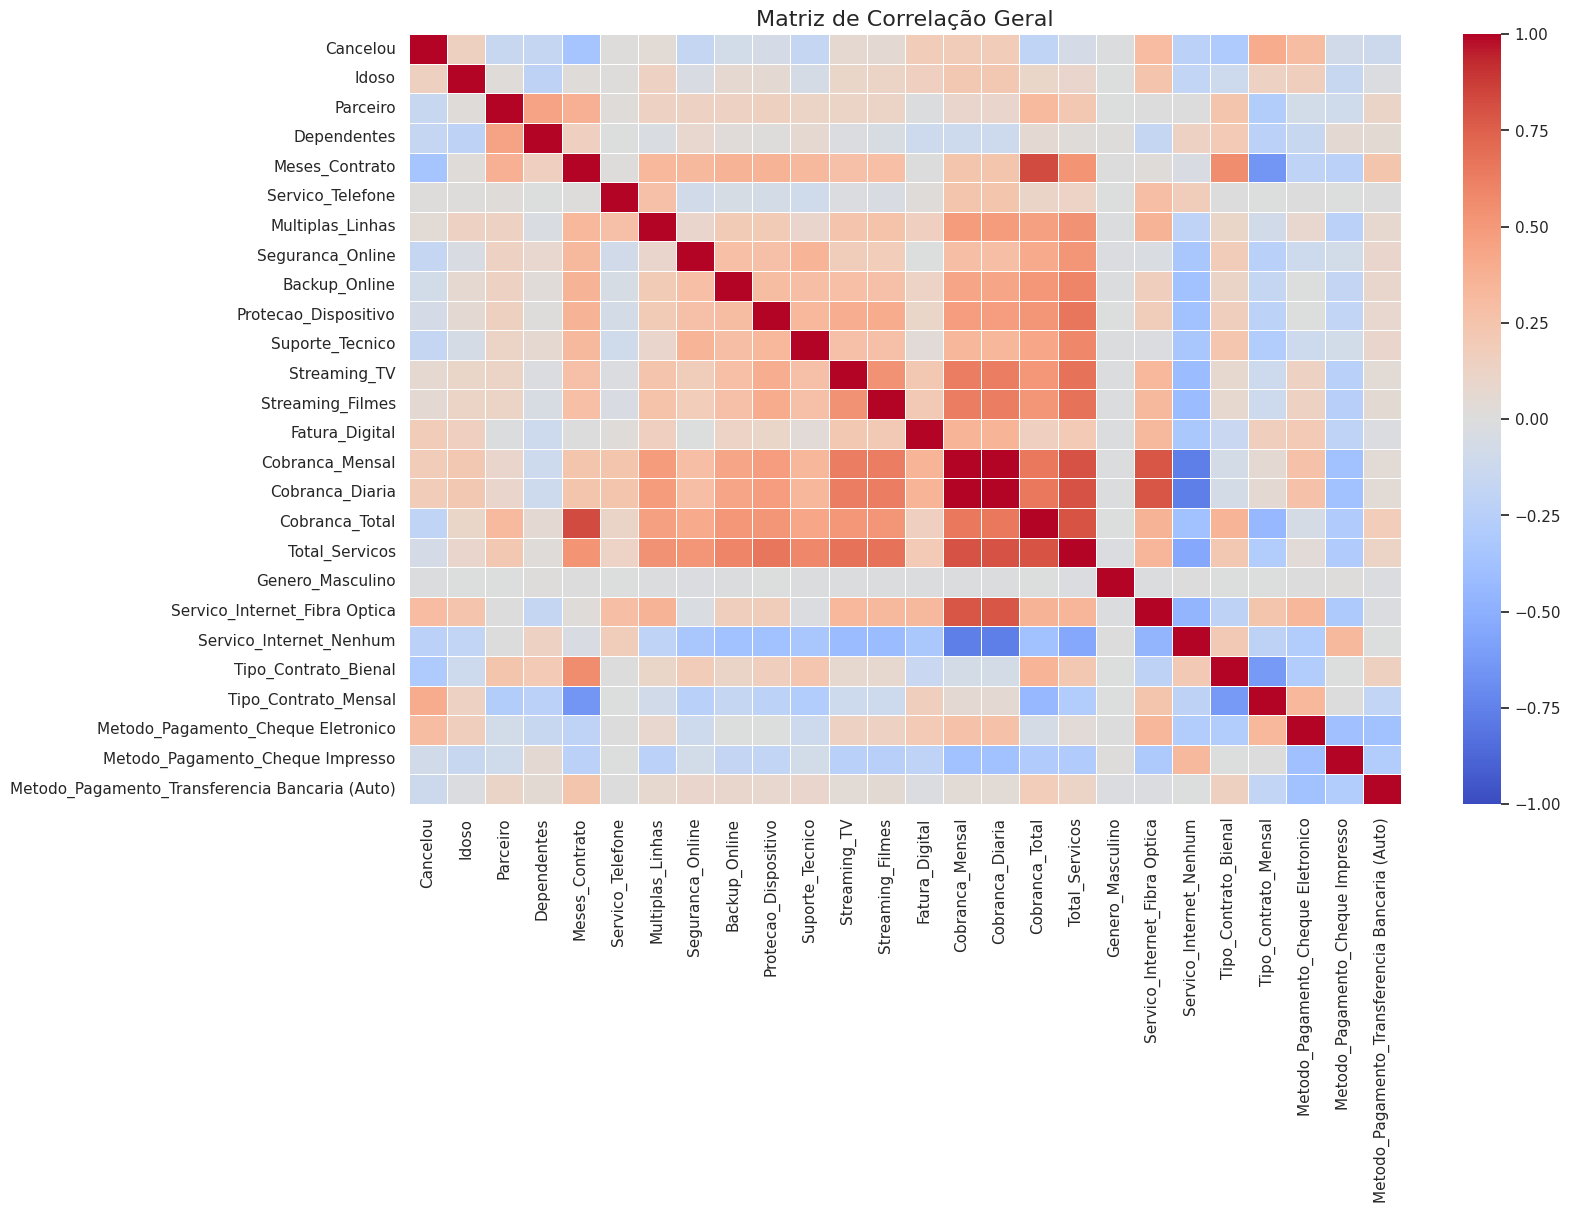

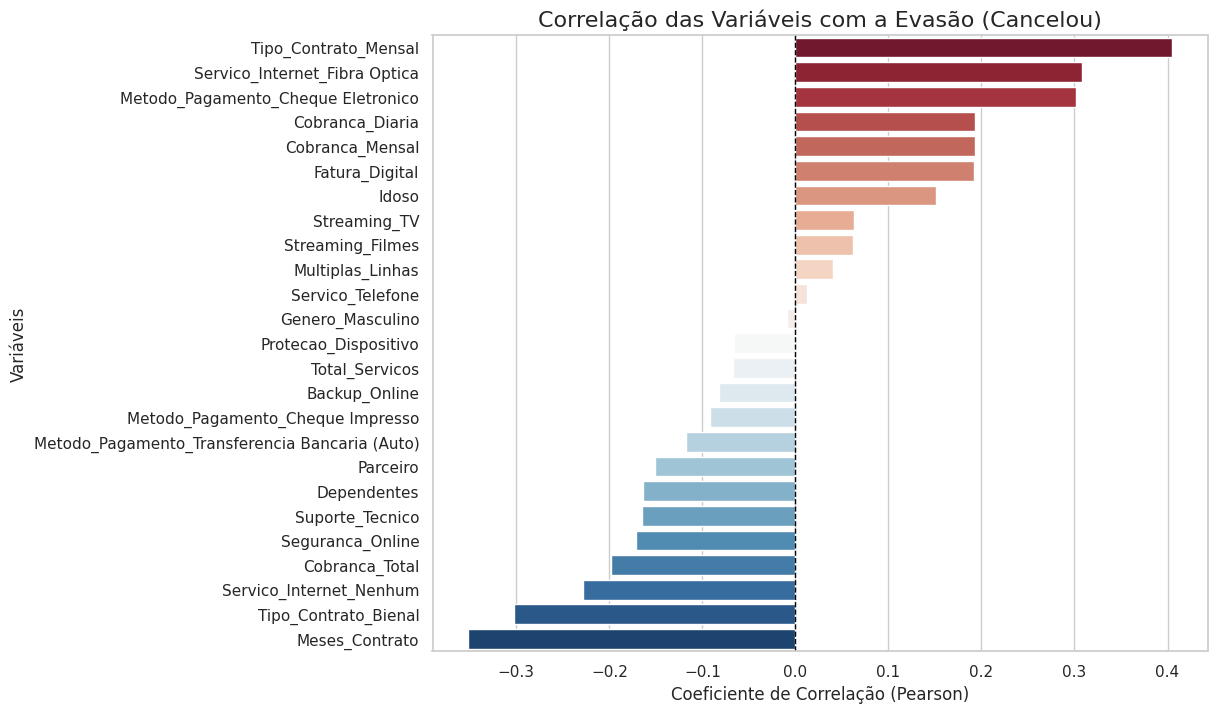

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

correlacao = df_telecom_encoded.corr()

plt.figure(figsize=(16, 10))
sns.heatmap(correlacao, annot=False, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação Geral', fontsize=16)
plt.show()

print("\n" + "="*50 + "\n")

correlacao_alvo = correlacao['Cancelou'].drop('Cancelou').sort_values(ascending=False)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=correlacao_alvo.values,
    y=correlacao_alvo.index,
    hue=correlacao_alvo.index,
    palette='RdBu',
    legend=False
)

plt.title('Correlação das Variáveis com a Evasão (Cancelou)', fontsize=16)
plt.xlabel('Coeficiente de Correlação (Pearson)')
plt.ylabel('Variáveis')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.show()

## Análises Direcionadas

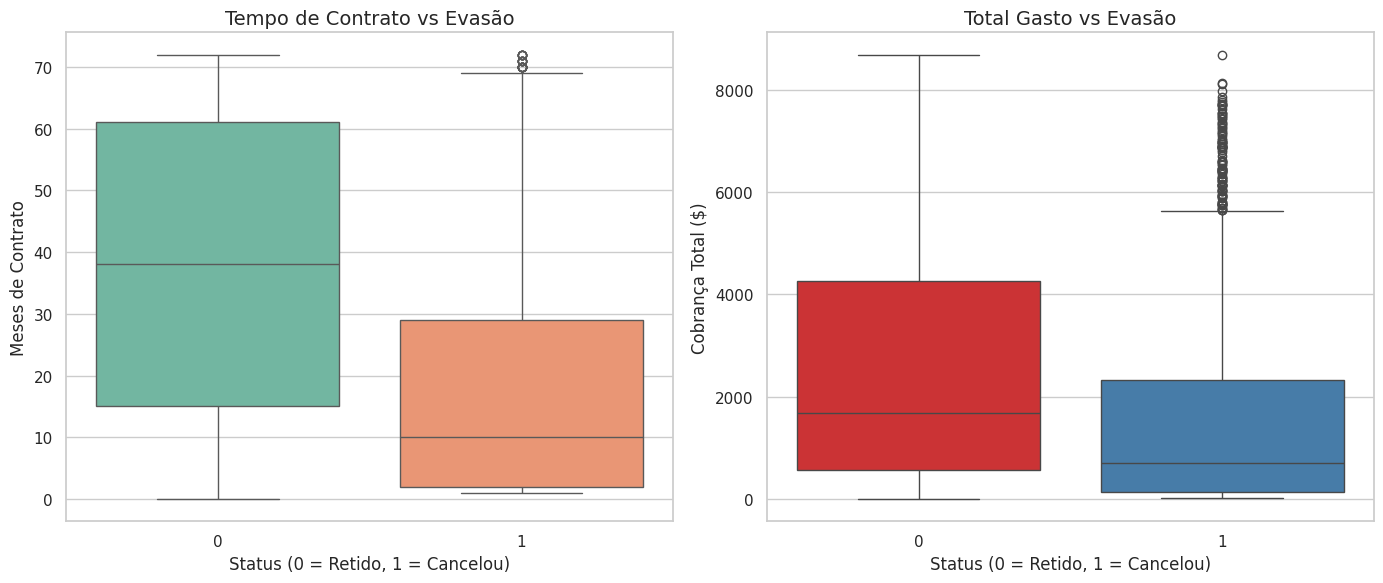

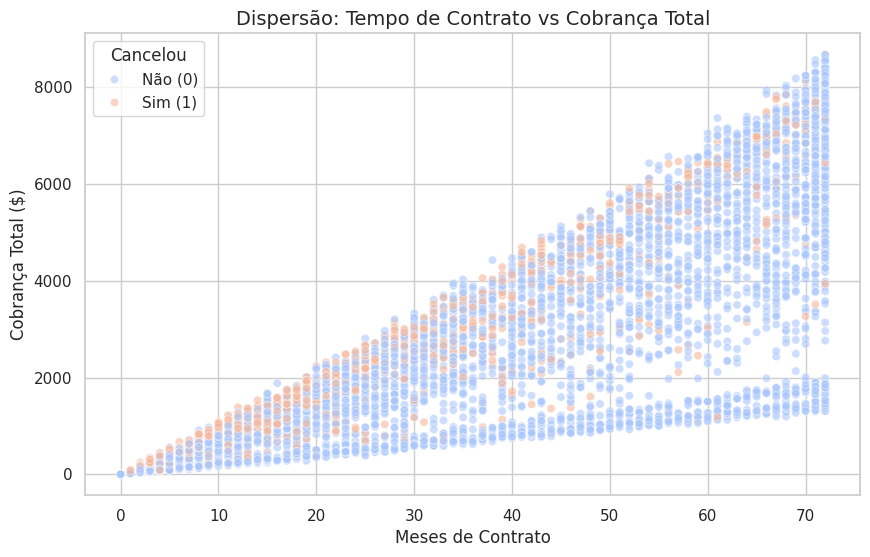

In [38]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_telecom_encoded, x='Cancelou', y='Meses_Contrato', hue='Cancelou', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Tempo de Contrato vs Evasão', fontsize=14)
axes[0].set_xlabel('Status (0 = Retido, 1 = Cancelou)', fontsize=12)
axes[0].set_ylabel('Meses de Contrato', fontsize=12)

sns.boxplot(data=df_telecom_encoded, x='Cancelou', y='Cobranca_Total', hue='Cancelou', ax=axes[1], palette='Set1', legend=False)
axes[1].set_title('Total Gasto vs Evasão', fontsize=14)
axes[1].set_xlabel('Status (0 = Retido, 1 = Cancelou)', fontsize=12)
axes[1].set_ylabel('Cobrança Total ($)', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "="*60 + "\n")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_telecom_encoded, x='Meses_Contrato', y='Cobranca_Total', hue='Cancelou', alpha=0.6, palette='coolwarm')
plt.title('Dispersão: Tempo de Contrato vs Cobrança Total', fontsize=14)
plt.xlabel('Meses de Contrato', fontsize=12)
plt.ylabel('Cobrança Total ($)', fontsize=12)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, title='Cancelou', labels=['Não (0)', 'Sim (1)'])
plt.show()

# 🤖 Modelagem Preditiva

## Separação de Dados

In [33]:
from sklearn.model_selection import train_test_split

X = df_telecom_encoded.drop('Cancelou', axis=1)
y = df_telecom_encoded['Cancelou']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("--- DIVISÃO DO CONJUNTO DE DADOS ---")
print(f"Total original: {df_telecom_encoded.shape[0]} linhas")
print(f"Dados de Treino (X_train): {X_train.shape[0]} linhas (80%)")
print(f"Dados de Teste (X_test): {X_test.shape[0]} linhas (20%)")

print("\n--- PROPORÇÃO DE CHURN (ESTRATIFICAÇÃO) ---")
print(f"Treino - Churn (1): {y_train.mean()*100:.2f}%")
print(f"Teste - Churn (1): {y_test.mean()*100:.2f}%")

--- DIVISÃO DO CONJUNTO DE DADOS ---
Total original: 7043 linhas
Dados de Treino (X_train): 5634 linhas (80%)
Dados de Teste (X_test): 1409 linhas (20%)

--- PROPORÇÃO DE CHURN (ESTRATIFICAÇÃO) ---
Treino - Churn (1): 26.54%
Teste - Churn (1): 26.54%


## Criação de Modelos

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

colunas_continuas = ['Meses_Contrato', 'Cobranca_Mensal', 'Cobranca_Total']

scaler = StandardScaler()

X_train_scaled = X_train_balanceado.copy()
X_test_scaled = X_test.copy()

X_train_scaled[colunas_continuas] = scaler.fit_transform(X_train_balanceado[colunas_continuas])
X_test_scaled[colunas_continuas] = scaler.transform(X_test[colunas_continuas])

modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train_scaled, y_train_balanceado)

modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)
modelo_rf.fit(X_train_balanceado, y_train_balanceado)

previsoes_lr = modelo_lr.predict(X_test_scaled)
previsoes_rf = modelo_rf.predict(X_test)

print("="*55)
print(" RESULTADOS: REGRESSÃO LOGÍSTICA (Com Dados Padronizados)")
print("="*55)
print(classification_report(y_test, previsoes_lr))

print("\n" + "="*55)
print(" RESULTADOS: RANDOM FOREST (Sem Padronização)")
print("="*55)
print(classification_report(y_test, previsoes_rf))

 RESULTADOS: REGRESSÃO LOGÍSTICA (Com Dados Padronizados)
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1035
           1       0.55      0.64      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409


 RESULTADOS: RANDOM FOREST (Sem Padronização)
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.56      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409



## Avaliação dos Modelos

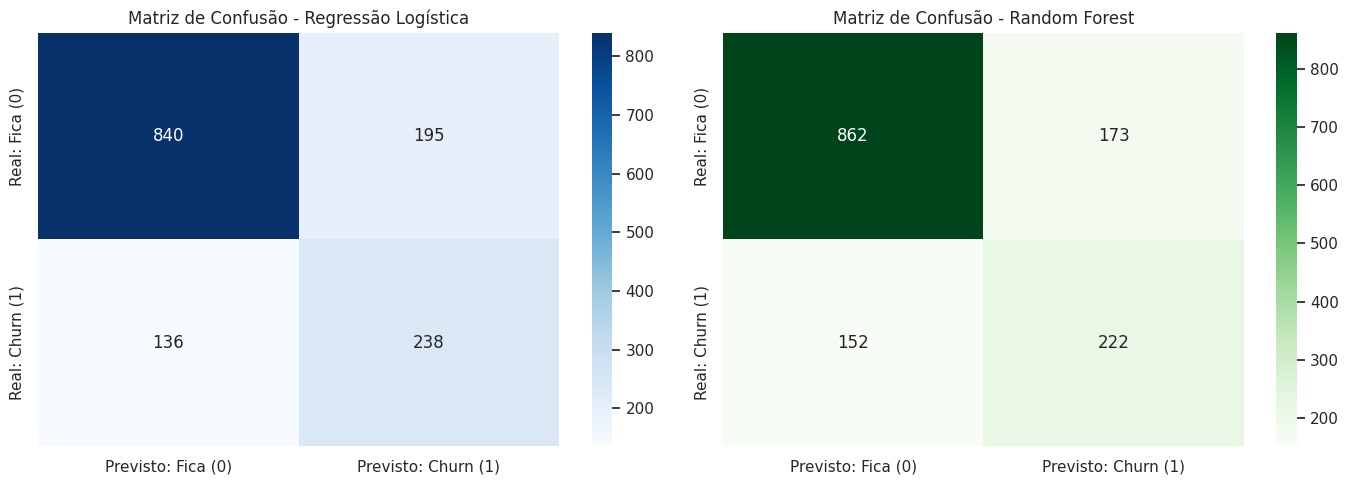


 DIAGNÓSTICO DE OVERFITTING / UNDERFITTING
Regressão Logística -> Acurácia Treino: 0.83 | Acurácia Teste: 0.77
Random Forest       -> Acurácia Treino: 1.00 | Acurácia Teste: 0.77


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, previsoes_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Previsto: Fica (0)', 'Previsto: Churn (1)'],
            yticklabels=['Real: Fica (0)', 'Real: Churn (1)'])
axes[0].set_title('Matriz de Confusão - Regressão Logística', fontsize=12)

cm_rf = confusion_matrix(y_test, previsoes_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Previsto: Fica (0)', 'Previsto: Churn (1)'],
            yticklabels=['Real: Fica (0)', 'Real: Churn (1)'])
axes[1].set_title('Matriz de Confusão - Random Forest', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print(" DIAGNÓSTICO DE OVERFITTING / UNDERFITTING")
print("="*50)

acc_treino_lr = accuracy_score(y_train_balanceado, modelo_lr.predict(X_train_scaled))
acc_teste_lr = accuracy_score(y_test, previsoes_lr)

acc_treino_rf = accuracy_score(y_train_balanceado, modelo_rf.predict(X_train_balanceado))
acc_teste_rf = accuracy_score(y_test, previsoes_rf)

print(f"Regressão Logística -> Acurácia Treino: {acc_treino_lr:.2f} | Acurácia Teste: {acc_teste_lr:.2f}")
print(f"Random Forest       -> Acurácia Treino: {acc_treino_rf:.2f} | Acurácia Teste: {acc_teste_rf:.2f}")

# 📋  Interpretação e Conclusões

## Análise de Importância das Variáveis

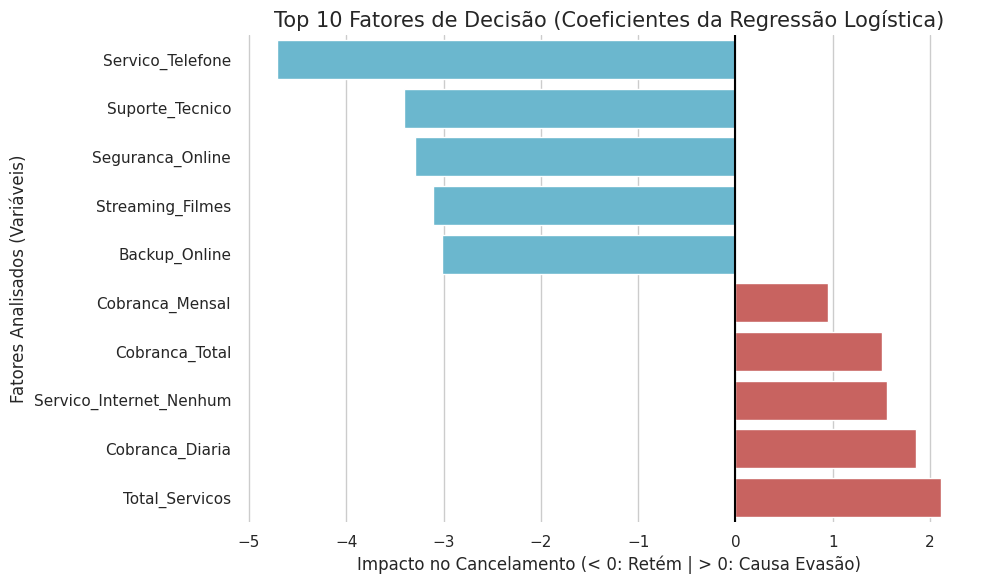


--- ANÁLISE DOS FATORES ---
Risco de Churn (+): As 5 variáveis que mais provocam cancelamentos (ex: Contrato Mensal)
Segurança de Retenção (-): As 5 variáveis que ajudam a manter o cliente ativo


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

features = X_train_scaled.columns
coeficientes = modelo_lr.coef_[0]

df_importancia = pd.DataFrame({'Variavel': features, 'Coeficiente': coeficientes})

df_importancia = df_importancia.sort_values(by='Coeficiente', ascending=False)

top_risco = df_importancia.head(5)
top_retencao = df_importancia.tail(5)

top_fatores = pd.concat([top_risco, top_retencao]).sort_values(by='Coeficiente', ascending=True)

plt.figure(figsize=(10, 6))

cores = ['#d9534f' if coef > 0 else '#5bc0de' for coef in top_fatores['Coeficiente']]

sns.barplot(x='Coeficiente', y='Variavel', data=top_fatores, palette=cores, hue='Variavel', legend=False)

plt.axvline(0, color='black', linestyle='-', linewidth=1.5)

plt.title('Top 10 Fatores de Decisão (Coeficientes da Regressão Logística)', fontsize=15)
plt.xlabel('Impacto no Cancelamento (< 0: Retém | > 0: Causa Evasão)', fontsize=12)
plt.ylabel('Fatores Analisados (Variáveis)', fontsize=12)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

print("\n--- ANÁLISE DOS FATORES ---")
print("Risco de Churn (+): As 5 variáveis que mais provocam cancelamentos (ex: Contrato Mensal)")
print("Segurança de Retenção (-): As 5 variáveis que ajudam a manter o cliente ativo")

## Conclusão

### Relatório Técnico: Análise Preditiva de Evasão de Clientes (Churn) e Estratégias de Retenção

**1. Avaliação e Seleção do Modelo Preditivo**
Para prever a evasão de clientes, foram desenvolvidos e comparados dois algoritmos de Machine Learning: Regressão Logística (com dados padronizados via `StandardScaler`) e Random Forest. Ambos os modelos foram treinados utilizando a técnica SMOTE para corrigir o desbalanceamento inicial da base de dados.

* **Desempenho Geral:** Ambos os modelos atingiram uma acurácia de 77% nos dados de teste.
* **Capacidade de Detecção (Recall):** A Regressão Logística obteve um desempenho superior na identificação de clientes propensos à evasão, alcançando um Recall de 64% para a classe alvo (Churn = 1), contra 59% do Random Forest.
* **Diagnóstico de Ajuste:** O Random Forest apresentou um quadro severo de *overfitting*, memorizando os dados de treino (acurácia de 100%) e perdendo capacidade de generalização no teste (77%). A Regressão Logística manteve um aprendizado saudável e consistente (83% no treino e 77% no teste).

**Conclusão da Modelagem:** A Regressão Logística foi o modelo selecionado. Além de não apresentar *overfitting*, sua capacidade superior de Recall garante que a empresa identifique um volume maior de clientes em risco, maximizando as oportunidades de retenção.

**2. Principais Fatores que Influenciam a Evasão**
A análise dos coeficientes da Regressão Logística permitiu isolar o peso matemático de cada variável na decisão do cliente. Os fatores foram divididos em dois grandes grupos:

* **Fatores de Risco (Impulsionam a Evasão):**
* **Custos e Frequência de Cobrança:** As variáveis `Total_Servicos`, `Cobranca_Diaria`, `Cobranca_Total` e `Cobranca_Mensal` apresentam as maiores correlações positivas com o cancelamento. Isso indica que pacotes fragmentados, com alto volume de serviços avulsos e cobranças frequentes, geram atrito financeiro e insatisfação.
* **Ausência de Conectividade:** A variável `Servico_Internet_Nenhum` é um forte gatilho de evasão. Clientes que utilizam apenas serviços básicos (sem internet) são altamente vulneráveis a ofertas da concorrência.


* **Fatores de Retenção (Fidelizam o Cliente):**
* **Serviço Base:** A variável `Servico_Telefone` possui o maior coeficiente negativo, atuando como a âncora principal de lealdade do cliente à operadora.
* **Ecossistema de Proteção e Entretenimento:** Serviços agregados de valor, como `Suporte_Tecnico`, `Seguranca_Online`, `Streaming_Filmes` e `Backup_Online`, criam fortes barreiras de saída. Quanto mais o cliente depende desse ecossistema integrado, menor é a probabilidade de cancelamento.



**3. Estratégias de Retenção Propostas**
Com base nos dados preditivos, o plano de ação focado na mitigação do *Churn* deve seguir três frentes estratégicas:

* **Reestruturação de Combos e Preços:** Como o volume total de serviços e as altas cobranças são os maiores vilões, a empresa deve unificar serviços avulsos em "Combos com Desconto Progressivo". Eliminar modelos de cobrança diária em favor de contratos mensais ou anuais com benefícios claros reduzirá o atrito financeiro.
* **Campanhas de Inclusão Digital (Upsell de Internet):** Criar ofertas agressivas e exclusivas de internet (como fibra óptica com desconto nos primeiros meses) direcionadas especificamente para o grupo identificado pela variável `Servico_Internet_Nenhum`, inserindo-os no ecossistema digital da empresa.
* **Democratização do Suporte e Segurança:** Como o suporte técnico e a segurança online provaram ser os maiores escudos contra a evasão, a operadora pode oferecer pacotes básicos desses serviços gratuitamente (ou a custo subsidiado) para clientes identificados pelo modelo preditivo como "alto risco", utilizando isso como moeda de troca para renovação de fidelidade.

